#  Depression Detection from Social Media Text


**Comparative Analysis of Binary Classification Models: Logistic Regression, Linear SVM, Decision Tree, and MLP**

Dataset: [Hugging Face — joangaes/depression](https://huggingface.co/datasets/joangaes/depression)

## 1. Imports & Setup

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))
RANDOM_STATE = 42
print('All packages loaded!')

All packages loaded!


## 2. Load Dataset

Shape: (27977, 2)
Columns: ['text', 'label']


,text,label
0,dear american teens question dutch person hear...,0
1,nothing look forward lifei dont many reasons k...,1
2,music recommendations im looking expand playli...,0
3,im done trying feel betterthe reason im still ...,1
4,worried year old girl subject domestic physic...,1


Label distribution:
label
0    14139
1    13838
Name: count, dtype: int64


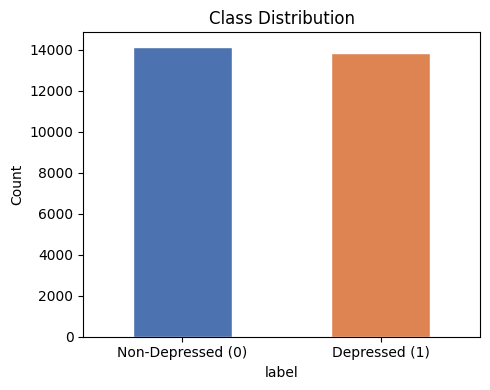

In [28]:
dataset = load_dataset("joangaes/depression")
df = pd.DataFrame(dataset['train'])

print(f'Shape: {df.shape}')
print('Columns:', df.columns.tolist())
display(df.head())

print('Label distribution:')
print(df['label'].value_counts())

# Plot
fig, ax = plt.subplots(figsize=(5,4))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white')
ax.set_xticklabels(['Non-Depressed (0)','Depressed (1)'], rotation=0)
ax.set_title('Class Distribution'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

## 3. Text Preprocessing

In [29]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'Dataset after cleaning: {len(df)} rows')
print('\nRaw   :', df['text'].iloc[2])
print('Clean :', df['clean_text'].iloc[2])

Dataset after cleaning: 27974 rows

Raw   : music recommendations im looking expand playlist usual genres alt pop minnesota hip hop steampunk various indie genres artists people like cavetown aliceband bug hunter penelope scott various rhymesayers willing explore new genresartists such anything generic rap the type exclusively sex drugs cool rapper is rap types pretty good pop popular couple years ago dunno technical genre name anyways anyone got music recommendations favorite artistssongs
Clean : music recommendations im looking expand playlist usual genres alt pop minnesota hip hop steampunk various indie genres artists people like cavetown aliceband bug hunter penelope scott various rhymesayers willing explore new genresartists anything generic rap type exclusively sex drugs cool rapper rap types pretty good pop popular couple years ago dunno technical genre name anyways anyone got music recommendations favorite artistssongs


## 4. Train / Validation / Test Split (70 / 15 / 15)
> Stratified split to preserve class balance.

In [30]:
X = df['clean_text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train : {len(X_train):>5}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):>5}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):>5}  ({len(X_test)/len(X)*100:.1f}%)')

Train : 19581  (70.0%)
Val   :  4196  (15.0%)
Test  :  4197  (15.0%)


## 5. TF-IDF Vectorization
> Fitted **only** on training data — transforms val/test separately to prevent data leakage.

In [31]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_vec = tfidf.fit_transform(X_train)  # fit + transform
X_val_vec   = tfidf.transform(X_val)        # transform only
X_test_vec  = tfidf.transform(X_test)       # transform only

print(f'Feature matrix shape (train): {X_train_vec.shape}')

Feature matrix shape (train): (19581, 20000)


## 6. Evaluation Helper Function

In [32]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    model.fit(X_tr, y_tr)
    results = {}
    for sname, Xs, ys in [('Train',X_tr,y_tr),('Val',X_v,y_v),('Test',X_te,y_te)]:
        preds = model.predict(Xs)
        results[sname] = {
            'accuracy':  accuracy_score(ys, preds),
            'precision': precision_score(ys, preds, pos_label=1, zero_division=0),
            'recall':    recall_score(ys, preds, pos_label=1, zero_division=0),
            'f1':        f1_score(ys, preds, pos_label=1, zero_division=0),
        }
    print(f'\n{"─"*54}')
    print(f'  {name}')
    print(f'{"─"*54}')
    print(f'  {"Split":<8} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
    for sname, m in results.items():
        print(f'  {sname:<8} {m["accuracy"]:>7.4f} {m["precision"]:>7.4f} {m["recall"]:>7.4f} {m["f1"]:>7.4f}')
    test_preds = model.predict(X_te)
    print(f'\n  Classification Report (Test):')
    print(classification_report(y_te, test_preds, target_names=['Non-Depressed','Depressed']))
    return model, results, test_preds

## 7. Model 1 — Logistic Regression
> Strong linear baseline for high-dimensional sparse text features.

In [33]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
lr_model, lr_results, lr_preds = evaluate_model(
    'Logistic Regression', lr,
    X_train_vec, y_train, X_val_vec, y_val, X_test_vec, y_test
)


──────────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  Train     0.9484  0.9553  0.9397  0.9474
  Val       0.9202  0.9286  0.9084  0.9184
  Test      0.9164  0.9247  0.9046  0.9145

  Classification Report (Test):
               precision    recall  f1-score   support

Non-Depressed       0.91      0.93      0.92      2121
    Depressed       0.92      0.90      0.91      2076

     accuracy                           0.92      4197
    macro avg       0.92      0.92      0.92      4197
 weighted avg       0.92      0.92      0.92      4197



## 8. Model 2 — Linear SVM
> Often achieves state-of-the-art on text classification with TF-IDF.

In [34]:
svm = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
svm_model, svm_results, svm_preds = evaluate_model(
    'Linear SVM', svm,
    X_train_vec, y_train, X_val_vec, y_val, X_test_vec, y_test
)


──────────────────────────────────────────────────────
  Linear SVM
──────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  Train     0.9925  0.9924  0.9926  0.9925
  Val       0.9187  0.9221  0.9128  0.9174
  Test      0.9164  0.9218  0.9080  0.9148

  Classification Report (Test):
               precision    recall  f1-score   support

Non-Depressed       0.91      0.92      0.92      2121
    Depressed       0.92      0.91      0.91      2076

     accuracy                           0.92      4197
    macro avg       0.92      0.92      0.92      4197
 weighted avg       0.92      0.92      0.92      4197



## 9. Model 3 — Decision Tree (Hyperparameter Tuning)
> Tune `max_depth` using validation F1 to prevent overfitting.

  max_depth=3      Val F1 = 0.7570
  max_depth=5      Val F1 = 0.7939
  max_depth=8      Val F1 = 0.8202
  max_depth=10     Val F1 = 0.8185
  max_depth=15     Val F1 = 0.8256
  max_depth=20     Val F1 = 0.8352
  max_depth=None   Val F1 = 0.8276

Best max_depth: 20


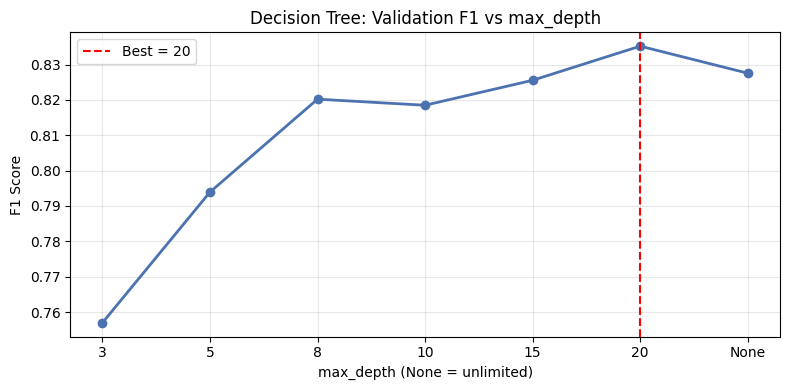

In [35]:
depths = [3, 5, 8, 10, 15, 20, None]
val_f1_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_vec, y_train)
    val_f1 = f1_score(y_val, dt.predict(X_val_vec), pos_label=1)
    val_f1_scores.append(val_f1)
    print(f'  max_depth={str(d):<5}  Val F1 = {val_f1:.4f}')

best_depth = depths[int(np.argmax(val_f1_scores))]
print(f'\nBest max_depth: {best_depth}')

plt.figure(figsize=(8,4))
plt.plot([str(d) for d in depths], val_f1_scores, marker='o', linewidth=2, color='#4C72B0')
plt.axvline(x=str(best_depth), color='red', linestyle='--', label=f'Best = {best_depth}')
plt.title('Decision Tree: Validation F1 vs max_depth')
plt.xlabel('max_depth (None = unlimited)'); plt.ylabel('F1 Score')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [36]:
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_model, dt_results, dt_preds = evaluate_model(
    f'Decision Tree (max_depth={best_depth})', dt_best,
    X_train_vec, y_train, X_val_vec, y_val, X_test_vec, y_test
)


──────────────────────────────────────────────────────
  Decision Tree (max_depth=20)
──────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  Train     0.9098  0.9558  0.8572  0.9038
  Val       0.8456  0.8842  0.7913  0.8352
  Test      0.8332  0.8675  0.7823  0.8227

  Classification Report (Test):
               precision    recall  f1-score   support

Non-Depressed       0.81      0.88      0.84      2121
    Depressed       0.87      0.78      0.82      2076

     accuracy                           0.83      4197
    macro avg       0.84      0.83      0.83      4197
 weighted avg       0.84      0.83      0.83      4197



## 10. Model 4 — Neural Network (MLP)


In [37]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=20,
    early_stopping=True,
    random_state=RANDOM_STATE
)

mlp_model, mlp_results, mlp_preds = evaluate_model(
    'MLP (1x128)',
    mlp,
    X_train_vec, y_train, X_val_vec, y_val, X_test_vec, y_test
)


──────────────────────────────────────────────────────
  MLP (1x128)
──────────────────────────────────────────────────────
  Split        Acc    Prec     Rec      F1
  Train     0.9760  0.9774  0.9740  0.9757
  Val       0.9268  0.9238  0.9287  0.9262
  Test      0.9228  0.9203  0.9239  0.9221

  Classification Report (Test):
               precision    recall  f1-score   support

Non-Depressed       0.93      0.92      0.92      2121
    Depressed       0.92      0.92      0.92      2076

     accuracy                           0.92      4197
    macro avg       0.92      0.92      0.92      4197
 weighted avg       0.92      0.92      0.92      4197



## 11. Confusion Matrices — All Models

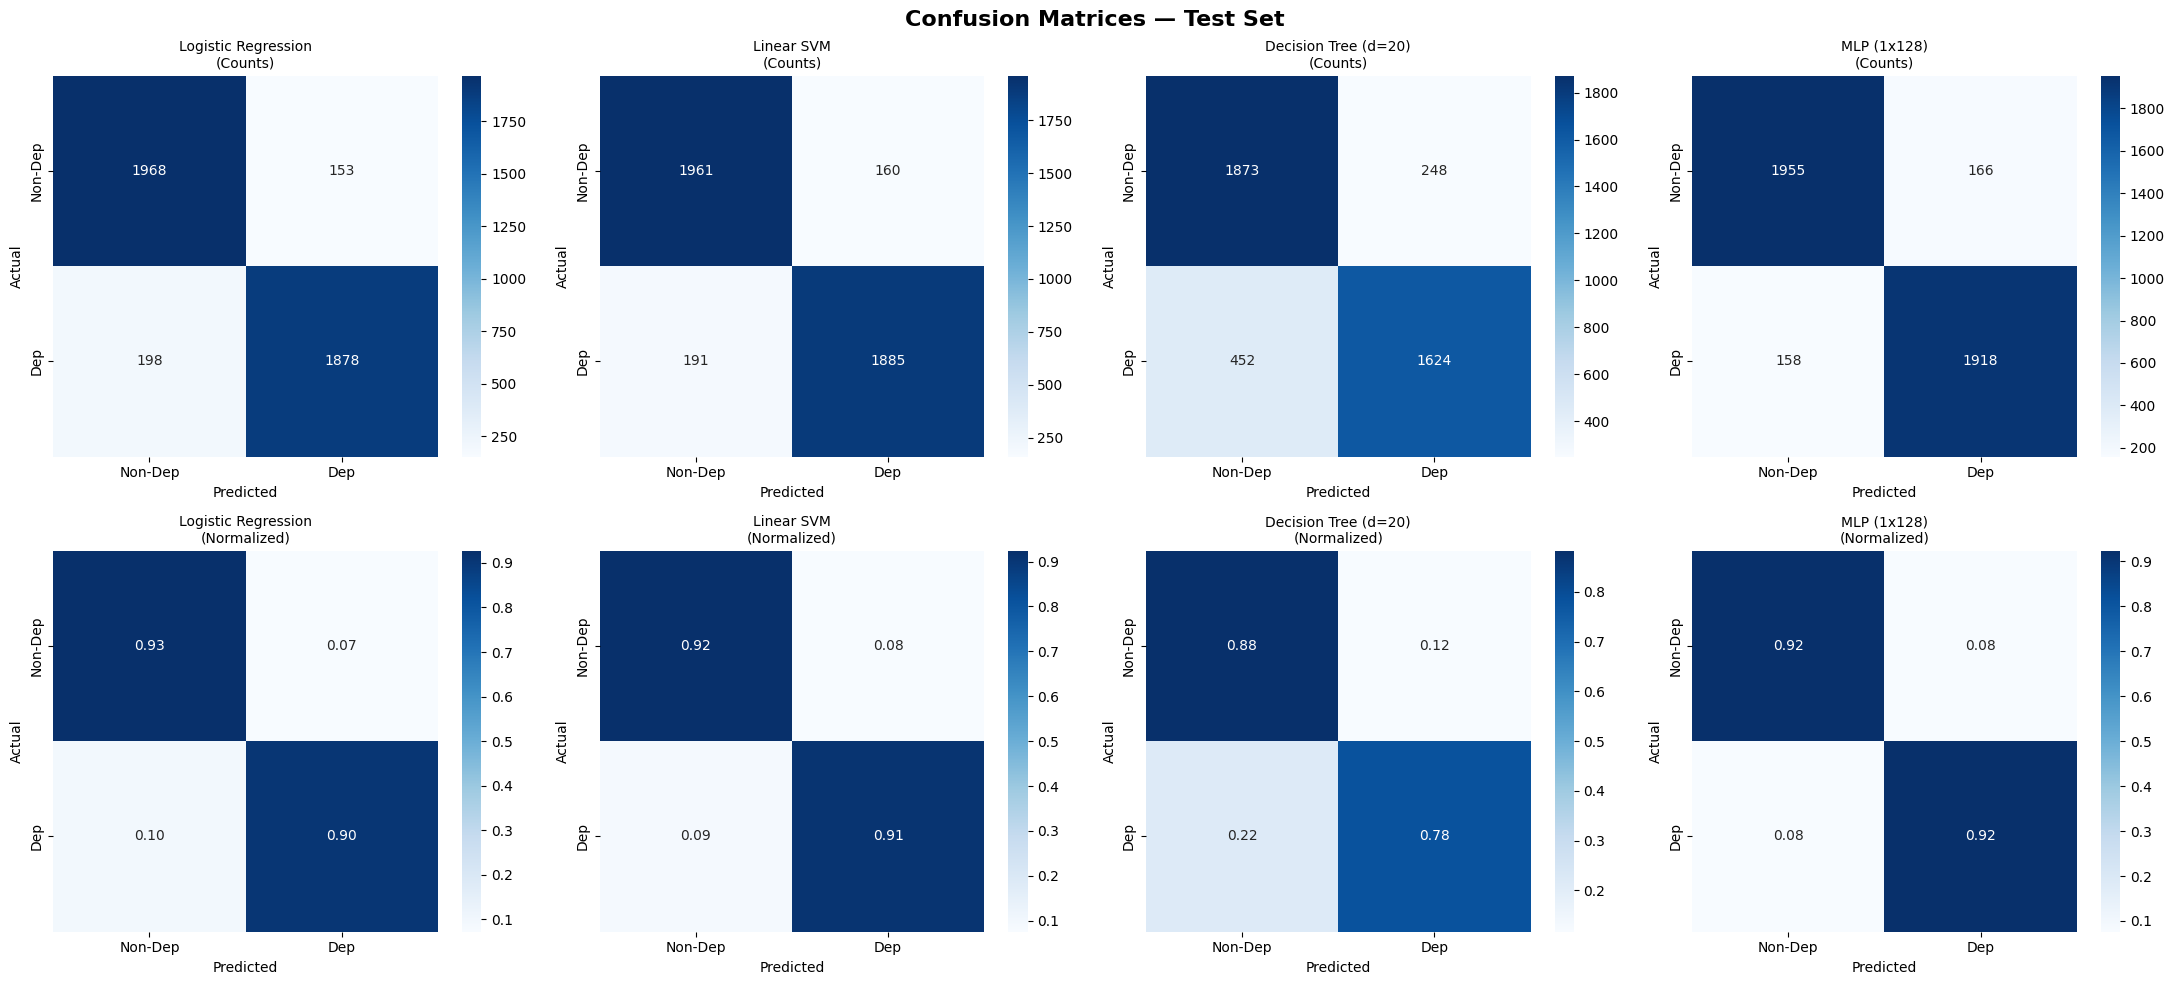

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Confusion Matrices — Test Set', fontsize=16, fontweight='bold')

models_info = [
    ('Logistic Regression', lr_preds),
    ('Linear SVM', svm_preds),
    (f'Decision Tree (d={best_depth})', dt_preds),
    ('MLP (1x128)', mlp_preds),
]

for col, (name, preds) in enumerate(models_info):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    for row, (matrix, fmt, sfx) in enumerate([(cm,'d','Counts'),(cm_norm,'.2f','Normalized')]):
        ax = axes[row][col]
        sns.heatmap(matrix, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=['Non-Dep','Dep'], yticklabels=['Non-Dep','Dep'])
        ax.set_title(f'{name}\n({sfx})', fontsize=10)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout(); plt.show()

## 12. Model Comparison Bar Chart

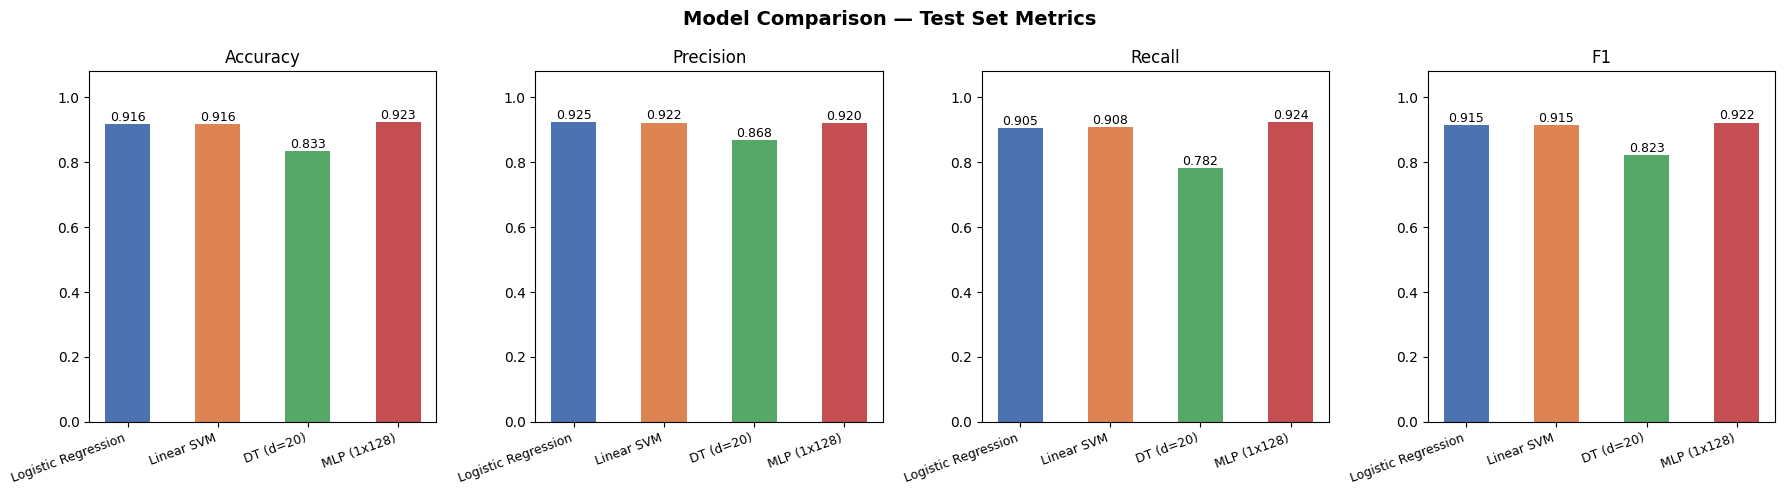

In [39]:
metrics = ['accuracy','precision','recall','f1']
all_results = [lr_results, svm_results, dt_results, mlp_results]
model_labels = ['Logistic Regression', 'Linear SVM',
                f'DT (d={best_depth})', 'MLP (1x128)']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(18,5))
fig.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')

for i, metric in enumerate(metrics):
    vals = [r['Test'][metric] for r in all_results]
    bars = axes[i].bar(model_labels, vals, color=colors, width=0.5)
    axes[i].set_title(metric.capitalize(), fontsize=12)
    axes[i].set_ylim(0, 1.08)
    axes[i].set_xticklabels(model_labels, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

## 13. Interpretability — Top LR Features by Coefficient

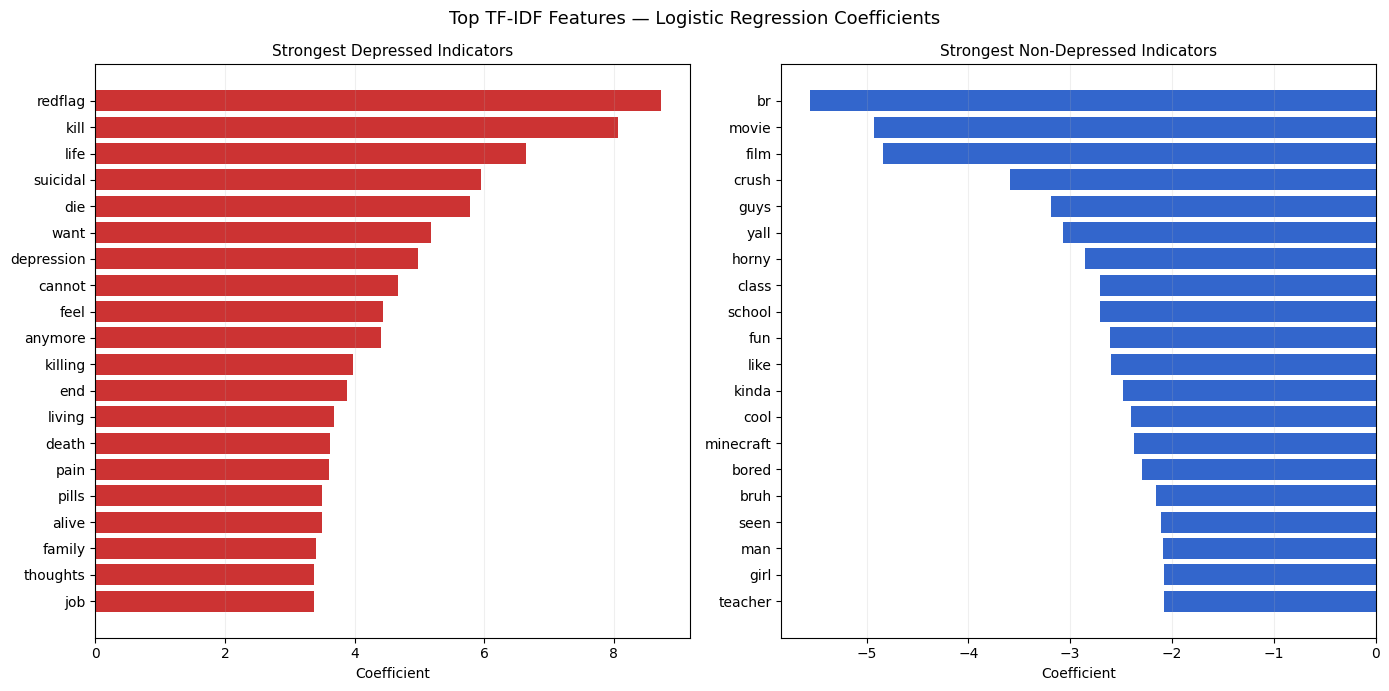

In [40]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Top TF-IDF Features — Logistic Regression Coefficients', fontsize=13)

for ax, idx, title, color in [
    (axes[0], np.argsort(coefs)[-top_n:][::-1], 'Strongest Depressed Indicators', '#CC3333'),
    (axes[1], np.argsort(coefs)[:top_n], 'Strongest Non-Depressed Indicators', '#3366CC'),
]:
    ax.barh(feature_names[idx][::-1], coefs[idx][::-1], color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Coefficient'); ax.grid(alpha=0.2, axis='x')

plt.tight_layout(); plt.show()

## 14. Final Summary Table

In [41]:
rows = []
for name, results in zip(
        ['Logistic Regression',
         'Linear SVM',
         f'Decision Tree (d={best_depth})',
         'MLP (1x128)'],
        [lr_results, svm_results, dt_results, mlp_results]):

    r = results['Test']
    rows.append({
        'Model': name,
        'Accuracy': round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1-Score': round(r['f1'], 4)
    })

summary = (
    pd.DataFrame(rows)
    .sort_values('F1-Score', ascending=False)
    .reset_index(drop=True)
)

display(summary)

best_model = summary.iloc[0]['Model']
print(f'\nBest model by F1: {best_model}')


print('\nKey: Recall is prioritized — missing a depressed post (FN) is more harmful than a false alarm (FP).')

,Model,Accuracy,Precision,Recall,F1-Score
0,MLP (1x128),0.9228,0.9203,0.9239,0.9221
1,Linear SVM,0.9164,0.9218,0.9080,0.9148
2,Logistic Regression,0.9164,0.9247,0.9046,0.9145
3,Decision Tree (d=20),0.8332,0.8675,0.7823,0.8227



Best model by F1: MLP (1x128)

Key: Recall is prioritized — missing a depressed post (FN) is more harmful than a false alarm (FP).


# 15. Discussion & Conclusions

## Overall Performance Comparison

This study evaluated four classifiers—Logistic Regression, Linear SVM, Decision Tree, and a shallow Multi-Layer Perceptron (MLP)—on TF-IDF representations of the depression dataset obtained from Hugging Face (`joangaes/depression`).

Although linear models typically dominate TF-IDF-based text classification, the **MLP (1×128 hidden layer)** achieved the best overall performance:


- **Accuracy:** 0.9228  
- **Precision:** 0.9203  
- **Recall:** 0.9239  
- **F1-score:** 0.9221  


Both Linear SVM and Logistic Regression performed strongly and nearly identically (F1 ≈ 0.915), confirming that linear models remain highly competitive baselines for sparse, high-dimensional text features. However, the MLP demonstrated consistent improvement across all evaluation metrics.

The Decision Tree significantly underperformed (F1 = 0.8227), highlighting the limitations of tree-based methods in high-dimensional sparse feature spaces.




## Interpretation of MLP Superiority

Although TF-IDF representations often favor linear classifiers, the MLP’s superior performance suggests:

- The dataset contains nonlinear feature interactions.  
- Emotional expression patterns may benefit from hidden-layer transformations.  
- Bigrams (`ngram_range=(1,2)`) introduce combinatorial structures that a shallow neural network can better exploit.  
- Regularization and early stopping successfully mitigated overfitting.  

The improvement in recall (0.9239 vs ~0.906 for linear models) is particularly important for this application.




## Overfitting Analysis

Overfitting was most evident in the Decision Tree model:

- High training performance  
- Significant drop on validation/test sets  

This behavior is expected because tree models partition sparse feature spaces aggressively, often memorizing token combinations.

In contrast:

- Logistic Regression and Linear SVM generalized well due to L2 regularization.  
- The MLP maintained stable performance due to early stopping and weight decay (`alpha` parameter).  

The relatively small gap between training and test metrics for the MLP indicates controlled model complexity.




## Metric Prioritization: Why Recall Matters Most

This task involves identifying potentially depressed posts. In such contexts:

> A false negative (missed depression case) is more harmful than a false positive.

The MLP achieved the highest recall (0.9239), meaning it detected the largest proportion of depressed posts.

While Logistic Regression achieved slightly higher precision (0.9247), it missed more positive cases. Under a risk-sensitive framework, maximizing recall is preferable.

Therefore, based on the predefined evaluation priority, the MLP is the most suitable model among those tested.




## Ethical Considerations

This project is conducted strictly for academic purposes.

Important limitations include:

- The classifier is not suitable for clinical diagnosis.  
- Labels are derived from self-reported social media posts, not clinical assessments.  
- Language on social media may include exaggeration, sarcasm, or contextual ambiguity.  
- Automated mental health classification systems may introduce:
  - False reassurance  
  - Unnecessary alarm  
  - Privacy concerns  
  - Potential stigmatization  

Any real-world deployment would require clinical validation, ethical oversight, and human-in-the-loop review mechanisms.




# 16. Future Work

Despite strong performance, several improvements could further enhance robustness and generalization:

### 1. Transformer-Based Models

Fine-tuning contextual models such as **DistilBERT** and **RoBERTa** may improve performance by capturing contextual semantics beyond TF-IDF representations.

### 2. Threshold Optimization

Rather than using a default probability threshold (0.5), tuning the threshold to maximize recall or Fβ (β > 1) could further reduce false negatives.

### 3. Cross-Dataset Generalization

Testing the model on different mental health datasets would assess robustness and domain transfer capability.

### 4. Model Explainability

Applying SHAP (SHapley Additive Explanations) would improve transparency by identifying which features most influence predictions.




# Final Conclusion

This study demonstrates that:

- Classical linear models remain strong baselines for TF-IDF text classification.  
- A properly regularized shallow neural network can outperform linear classifiers when nonlinear interactions are present.  
- Model selection must align with application risk priorities—in this case, recall.  

The results highlight that model complexity alone does not guarantee superiority; careful validation, regularization, and metric alignment are more critical than architectural depth.